In [ ]:
#Python implementation
#Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

In [ ]:
#Sample data: Area in square feet(X) and corresponding house prices in $1000s(y)
#For simplicity ,let's simulate a linear relationship : price = 50*area +some noise
data={
    'area':[650,800,950,1100,1250,1400,1550,1700,1850,2000],

    'location':['Lucknow','Mumbai','Delhi','Lucknow','Mumbai','Delhi','Lucknow','Mumbai','Delhi','Lucknow'],
    'price':[325,450,380,550,700,580,775,950,830,1000]
}
df=pd.DataFrame(data)
df =pd.get_dummies(df,columns=['location'],dtype=int)
print(df)

   area  price  location_Delhi  location_Lucknow  location_Mumbai
0   650    325               0                 1                0
1   800    450               0                 0                1
2   950    380               1                 0                0
3  1100    550               0                 1                0
4  1250    700               0                 0                1
5  1400    580               1                 0                0
6  1550    775               0                 1                0
7  1700    950               0                 0                1
8  1850    830               1                 0                0
9  2000   1000               0                 1                0


In [ ]:
x=df.drop(columns=['price'])
y=df['price']

print(x)
print(y)

   area  location_Delhi  location_Lucknow  location_Mumbai
0   650               0                 1                0
1   800               0                 0                1
2   950               1                 0                0
3  1100               0                 1                0
4  1250               0                 0                1
5  1400               1                 0                0
6  1550               0                 1                0
7  1700               0                 0                1
8  1850               1                 0                0
9  2000               0                 1                0
0     325
1     450
2     380
3     550
4     700
5     580
6     775
7     950
8     830
9    1000
Name: price, dtype: int64


In [ ]:
#Create a linear Regression model
model=LinearRegression()

In [ ]:
#Train the model with the data
model.fit(x,y)
print(model.coef_)
print(model.intercept_)

[  0.51234568 -94.81481481   9.44444444  85.37037037]
-25.80246913580254


In [ ]:
#Make predictions on the same data to visualize the line of best fit
y_pred=model.predict(x)

In [ ]:
#Print model parameters
print("Model Coefficient (Slope): ",model.coef_[0])
print("Model Intercept: ",model.intercept_)
print("Mean squared error: ",mean_squared_error(y,y_pred))

Model Coefficient (Slope):  0.5123456790123457
Model Intercept:  -25.80246913580254
Mean squared error:  138.88888888888863


In [ ]:
#Predict price for the new house (eg. for 1600 sq. ft)
cities=["Lucknow","Delhi","Mumbai"]
for city in cities:
  new_area=pd.DataFrame({
    'area':[1200],
    'location_Delhi':[1 if city=='Delhi' else 0],
    'location_Lucknow':[1 if city =='Lucknow' else 0],
    'location_Mumbai':[1 if city =='Mumbai' else 0 ]
  })
  predicted_price=model.predict(new_area)[0]
  print(f"\nPredicted price for 1600 sq. ft in {city}: ${predicted_price * 1000:.2f} ")



Predicted price for 1600 sq. ft in Lucknow: $598456.79 

Predicted price for 1600 sq. ft in Delhi: $494197.53 

Predicted price for 1600 sq. ft in Mumbai: $674382.72 


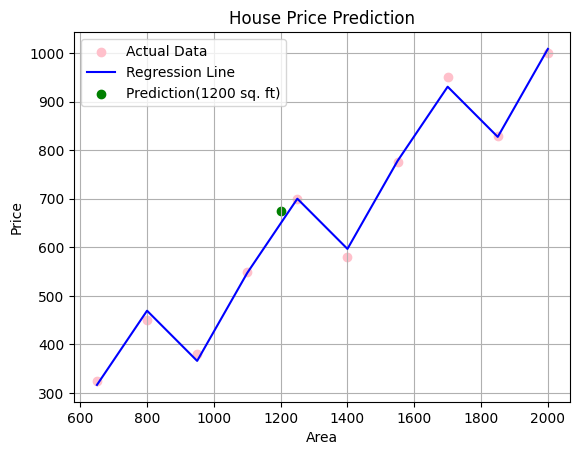

In [ ]:
#Plotting
plt.scatter(df['area'],y,color='pink',label='Actual Data')
plt.plot(df['area'],y_pred,color='blue',label='Regression Line ')
plt.scatter(new_area['area'],predicted_price,color="green",label='Prediction(1200 sq. ft)')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Price Prediction")
plt.legend()
plt.grid(True)
plt.show()